In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
from tqdm import tqdm
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttri

Using device: cuda:0


In [2]:
dataset = "urban4"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm, Y_up, new_H = rsfm.create_fm("DOFA", Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_up, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=1, use_cls=False)

In [3]:
def train_model(Y, fm, B, c, D, alpha, new_H):
    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))
    
    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, use_cls=False, is_cnnaeu=False)
    # model = torch.compile(model)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y/Y.max(), c, is_unmixer=True, normalize=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):

        optimizer.zero_grad()
        Y = Y.to(dev)
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, Y_hat = model(features)
        # W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.6, 0.09, 3e-5, 0, 0
        # loss = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)
        loss = model.loss(Y, Y_hat, A_hat, E_hat)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
    

    model.eval()

    with torch.no_grad():
        _, _, features = rsfm.extract_f(fm, Y, new_H, wavelengths, A,use_cls=False)
        E_hat, A_hat, _ = model(features)
    
    return E_hat, A_hat

  0%|          | 0/3 [00:00<?, ?it/s]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 33%|███▎      | 1/3 [01:10<02:20, 70.06s/it]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 67%|██████▋   | 2/3 [02:19<01:09, 69.80s/it]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


100%|██████████| 3/3 [03:29<00:00, 69.77s/it]


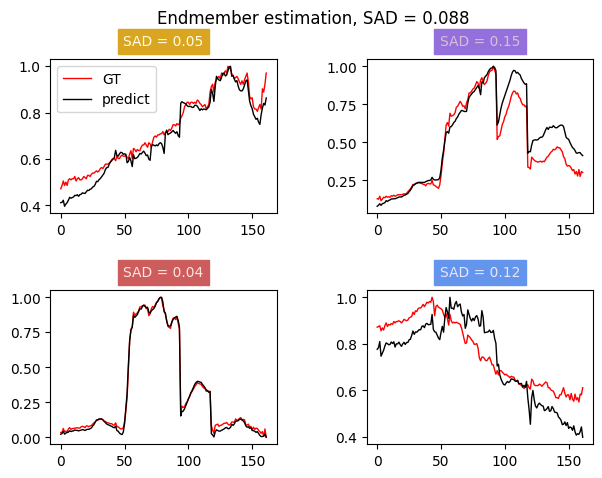

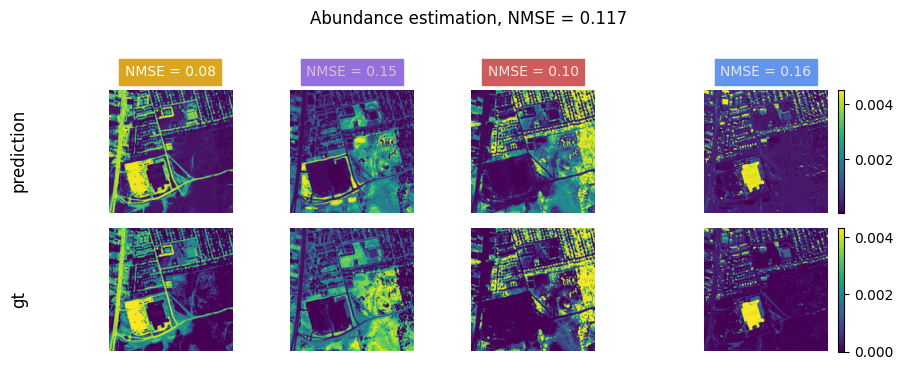

In [4]:
padding = 8
shift = 8

n_xp = 1
E_hats_pad, A_hats_pad, E_hats_base, A_hats_base = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H+2*padding, H+2*padding), torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H, H)
sads_base, mses_base, sads_pad, mses_pad = [], [], [], []

for n in range(n_xp):
    Y_padded = F.pad(Y_init, pad=(padding, padding, padding, padding), mode="reflect")
    A_hat_padded = torch.zeros(1, c, H+2*padding,H+2*padding)
    weights = torch.zeros_like(A_hat_padded)

    E_hats = torch.zeros((2*padding+1)**2, B, c)
    A_hat_list = []
    E_hat_list = []

    for i in tqdm(range(0, 2*padding + 1, shift)):
        for j in range(0, 2*padding + 1, shift):

            Y_crop = Y_padded[:, :, i:i+H, j:j+H]
            
            E_hat, A_hat = train_model(Y_crop, fm, B, c, D, alpha, H)
            
            A_hat_list.append(A_hat)
            E_hat_list.append(E_hat)

            E_hats[i+j] = E_hat
            A_hat_padded[:, :, i:i+H, j:j+H] += A_hat
            weights[:, :, i:i+H, j:j+H] += 1

    A_hat_padded /= weights
    E_hat_m = torch.mean(E_hats, dim=0)
    # E_hats_pad[n] = E_hat_mop: SAD = {torch.mean(torch.tensor(sads_pad))} ± {torch.std(torch.tensor(sads_pad))}, NMSE = {torch.mean(torch.tensor(mses_pad))} ± {torch.std(torch.tensor(mses_pad))}")
    # print(f"Base: SAD = {torch.mean(torch.tensor(sads_base))} ± {torch.std(torch.tensor(sads_base))}, NMSE = {torch.mean(torch.tensor(mses_base))} ± {torch.std(torch.tensor(mses_base))}")
    # A_hats_pad[n] = A_hat_padded

    # E_hat_base, A_hat_base = train_model(Y_init, fm, B, c, D, alpha, H)
    # E_hats_base[n] = E_hat_base
    # A_hats_base[n] = A_hat_base

    # sad_base, _, mse_base = plots.compute_metrics_and_plot(E_hat_base, A_hat_base, A_init, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    # sad_base, _, mse_base = plots.compute_metrics_and_plot(E_hat_base, A_hat_base[:,:,padding:-1-padding, padding:-1-padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat_m, A_hat_padded[:,:,padding*2:-1-2*padding, padding*2:-1-2*padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)
    # sads_base.append(sad_base)
    # mses_base.append(mse_base)
    # sads_pad.append(sad_pad)
    # mses_pad.append(mse_pad)

# E_hat_m = torch.mean(E_hats_base, dim=0)
# A_hat_m = torch.mean(A_hats_base, dim=0)
# plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E_init, normalize_E=True, normalize_A=True)
# print(f"Multi-crop: SAD = {torch.mean(torch.tensor(sads_pad))} ± {torch.std(torch.tensor(sads_pad))}, NMSE = {torch.mean(torch.tensor(mses_pad))} ± {torch.std(torch.tensor(mses_pad))}")
# print(f"Base: SAD = {torch.mean(torch.tensor(sads_base))} ± {torch.std(torch.tensor(sads_base))}, NMSE = {torch.mean(torch.tensor(mses_base))} ± {torch.std(torch.tensor(mses_base))}")

In [5]:
sads_l = []
mse_l = []
A_init_pad = F.pad(A_init, pad=(4,4,4,4), mode="reflect")

j = 0
for i in range(len(E_hat_list)):
    x_i = (i//3)
    y_i = (i%3)*4
    A_gt = A_init_pad[:, x_i:x_i+H, y_i:y_i+H]

    sad_val, _, mse_val = plots.compute_metrics_and_plot(E_hat_list[i], A_hat_list[i], A_gt, E_init, normalize_A=True, normalize_E=True, return_results=True, plot_A=False, plot_E=False)
    sads_l.append(sad_val)
    mse_l.append(mse_val)

    j += 4

sad_std = torch.std(torch.tensor(sads_l))
sad_mean = torch.mean(torch.tensor(sads_l))
mse_std = torch.std(torch.tensor(mse_l))
mse_mean = torch.mean(torch.tensor(mse_l))

print("SAD : ", sad_mean, "±", sad_std)
print("MSE : ", mse_mean, "±", mse_std)

SAD :  tensor(0.1024, device='cuda:0') ± tensor(0.0304, device='cuda:0')
MSE :  tensor(0.6006, device='cuda:0') ± tensor(0.0762, device='cuda:0')


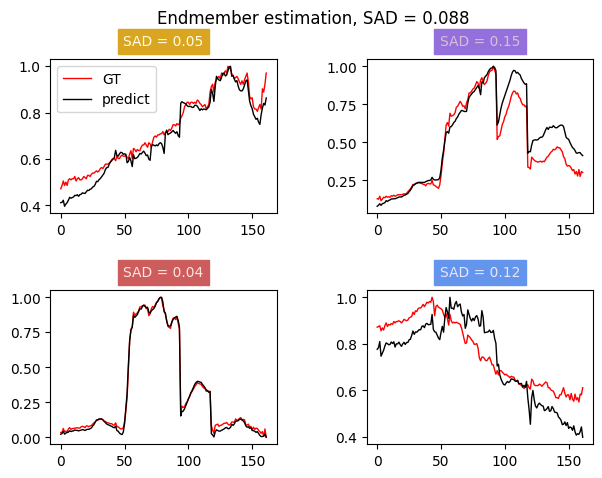

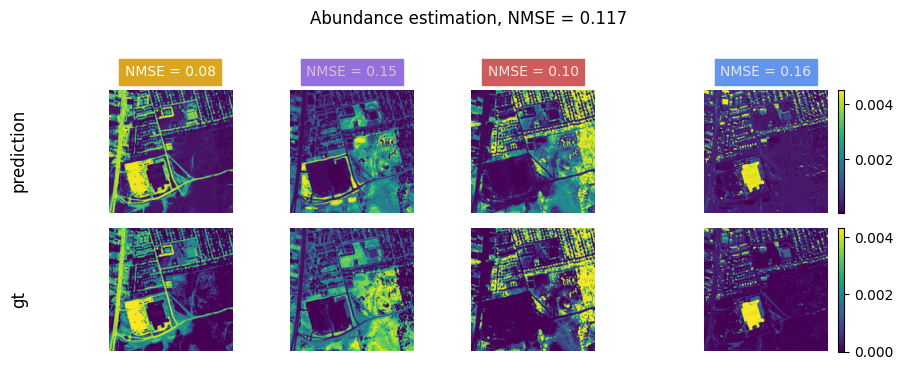

In [6]:
sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat_m, A_hat_padded[:,:,padding*2:-1-2*padding, padding*2:-1-2*padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True)

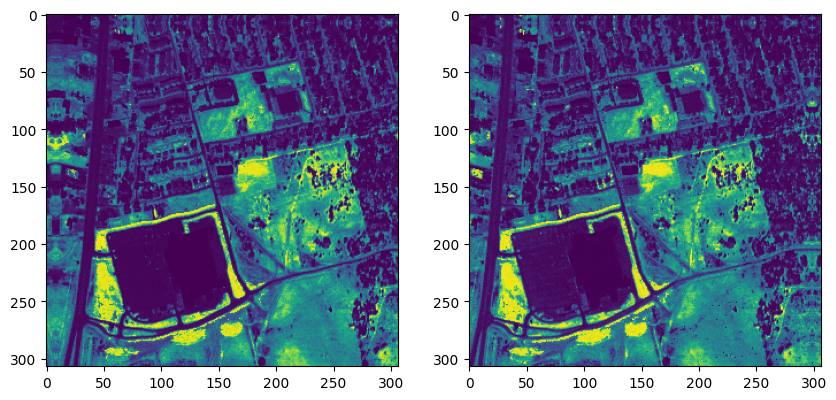

In [7]:
fig, axs = plt.subplots(1,2, figsize=(10,10))

axs[0].imshow(A_hat_list[0][0,0].cpu())
axs[1].imshow(A_hat_list[2][0,0].cpu())